# Arkham Data Science Challenge

In [5]:
import requests as rq
import pandas as pd
import openpyxl
import time
from datetime import date, timedelta
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

## Task 1: Data extraction

In [6]:
nodos = pd.read_excel('catalogonodos.xlsx', header = 1)
nodos.columns

Index(['SISTEMA', 'CENTRO DE CONTROL REGIONAL', 'ZONA DE CARGA', 'CLAVE',
       'NOMBRE', 'NIVEL DE TENSIÓN (kV)', 'DIRECTAMENTE MODELADA',
       'INDIRECTAMENTE MODELADA', 'DIRECTAMENTE MODELADA.1',
       'INDIRECTAMENTE MODELADA.1', 'ZONA DE OPERACIÓN DE TRANSMISIÓN',
       'GERENCIA REGIONAL DE TRANSMISIÓN', 'ZONA DE DISTRIBUCIÓN',
       'GERENCIA DIVISIONAL DE DISTRIBUCIÓN',
       'CLAVE DE ENTIDAD FEDERATIVA (INEGI)', 'ENTIDAD FEDERATIVA (INEGI)',
       'CLAVE DE MUNICIPIO (INEGI)', 'MUNICIPIO (INEGI)',
       'REGION DE TRANSMISION'],
      dtype='str')

In [8]:
len(nodos)

2585

In [ ]:
#True if ('Monclova' in nodos['ZONA DE CARGA'].unique()) else False
nodos['ZONA DE CARGA'].unique()

<StringArray>
[      'ENSENADA',       'MEXICALI',        'SANLUIS',        'TIJUANA',
      'No Aplica',   'CONSTITUCION',         'LA PAZ',      'LOS CABOS',
 'CENTRO ORIENTE',     'CENTRO SUR',
 ...
         'XALAPA',    'ZIHUATANEJO',       'CAMPECHE',         'CANCUN',
         'CARMEN',       'CHETUMAL',         'MERIDA',  'MOTUL TIZIMIN',
   'RIVIERA MAYA',          'TICUL']
Length: 109, dtype: str

In [ ]:
nodos_mclv = nodos[nodos['ZONA DE CARGA'].str.lower() == 'monclova']
nodos_mclv_str = ','.join(nodos_mclv['CLAVE'])
nodos_mclv_str

'06AEO-115,06AHM-400,06FRO-115,06GRA-115,06MON-115,06MON-230,06RGS-115,06TKS-115,06XOC-115'

In [ ]:
sistema = 'SIN'
proceso = 'MDA'
lista_nodos = nodos_mclv_str
anio_ini = '2024'
mes_ini = '01'
dia_ini = '01'
anio_fin = '2024'
mes_fin = '01'
dia_fin = '02'
formato = 'JSON'

url = f'https://ws01.cenace.gob.mx:8082/SWPML/SIM/{sistema}/{proceso}/{lista_nodos}/{anio_ini}/{mes_ini}/{dia_ini}/{anio_fin}/{mes_fin}/{dia_fin}/{formato}'
respuesta = rq.get(url)

if respuesta.status_code == 200:
    
    # 3. Conviertes la respuesta directamente a un diccionario de Python
    datos_json = respuesta.json()
    
    # Aquí ya puedes acceder a datos_json['Resultados'] y procesarlos
    print(f"DAtos para el request a {url}")
    # 1. Load the in-memory JSON data directly
    df = pd.DataFrame(datos_json)

    # Save as CSV
    #df.to_csv("resultado.csv", index=False)
    df = df['Resultados']
    print(df)
else:
    print(f"Ups, error en el servidor: {respuesta.status_code}")

# 4. Haces una pequeña pausa antes de la siguiente vuelta del bucle
time.sleep(2)

DAtos para el request a https://ws01.cenace.gob.mx:8082/SWPML/SIM/SIN/MDA/06AEO-115,06AHM-400,06FRO-115,06GRA-115,06MON-115,06MON-230,06RGS-115,06TKS-115,06XOC-115/2024/01/01/2024/01/02/JSON
0    {'clv_nodo': '06AEO-115', 'Valores': [{'fecha'...
1    {'clv_nodo': '06AHM-400', 'Valores': [{'fecha'...
2    {'clv_nodo': '06FRO-115', 'Valores': [{'fecha'...
3    {'clv_nodo': '06GRA-115', 'Valores': [{'fecha'...
4    {'clv_nodo': '06MON-115', 'Valores': [{'fecha'...
5    {'clv_nodo': '06MON-230', 'Valores': [{'fecha'...
6    {'clv_nodo': '06RGS-115', 'Valores': [{'fecha'...
7    {'clv_nodo': '06TKS-115', 'Valores': [{'fecha'...
8    {'clv_nodo': '06XOC-115', 'Valores': [{'fecha'...
Name: Resultados, dtype: object


In [ ]:
def flattenData(form):
    flattenedRows = []
    for nodo in form['Resultados']:
        clave = nodo['clv_nodo']
        for valores in nodo['Valores']:
            valores['nodo'] = clave 
            flattenedRows.append(valores)

    return pd.DataFrame(flattenedRows)

In [ ]:
flattenData(datos_json)

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo
0,2024-01-01,1,279.92,370.71,-43.69,-47.1,06AEO-115
1,2024-01-01,2,279.21,311.75,-32.54,0,06AEO-115
2,2024-01-01,3,274.23,305.52,-31.28,0,06AEO-115
3,2024-01-01,4,264.01,294.23,-30.22,0,06AEO-115
4,2024-01-01,5,243.44,267.66,-24.22,0,06AEO-115
...,...,...,...,...,...,...,...
427,2024-01-02,20,594.32,649.19,-54.86,0,06XOC-115
428,2024-01-02,21,392.26,431.03,-38.77,0,06XOC-115
429,2024-01-02,22,592.27,646.27,-52.38,-1.62,06XOC-115
430,2024-01-02,23,490.33,535.61,-45.28,0,06XOC-115


In [ ]:
def getRequestURLs(startDate, endDate, lista_nodos, sistema='SIN', proceso='MDA', formato='JSON'):
    URLlist = []
    current_date = startDate
    
    while current_date <= endDate: 
    
        chunk_end = current_date + timedelta(days=6)
        if chunk_end > endDate:
            chunk_end = endDate

        # .strftime("%Y/%m/%d") asegura el formato exacto que pide el CENACE
        f_ini = current_date.strftime("%Y/%m/%d")
        f_fin = chunk_end.strftime("%Y/%m/%d")
        
        url = f"https://ws01.cenace.gob.mx:8082/SWPML/SIM/{sistema}/{proceso}/{lista_nodos}/{f_ini}/{f_fin}/{formato}"

        URLlist.append(url)

        current_date = chunk_end + timedelta(days=1)
        
    return URLlist

In [ ]:
urlList = getRequestURLs(date(2024,1,1), date(2025,6,30), nodos_mclv_str)
urlList

['https://ws01.cenace.gob.mx:8082/SWPML/SIM/SIN/MDA/06AEO-115,06AHM-400,06FRO-115,06GRA-115,06MON-115,06MON-230,06RGS-115,06TKS-115,06XOC-115/2024/01/01/2024/01/07/JSON',
 'https://ws01.cenace.gob.mx:8082/SWPML/SIM/SIN/MDA/06AEO-115,06AHM-400,06FRO-115,06GRA-115,06MON-115,06MON-230,06RGS-115,06TKS-115,06XOC-115/2024/01/08/2024/01/14/JSON',
 'https://ws01.cenace.gob.mx:8082/SWPML/SIM/SIN/MDA/06AEO-115,06AHM-400,06FRO-115,06GRA-115,06MON-115,06MON-230,06RGS-115,06TKS-115,06XOC-115/2024/01/15/2024/01/21/JSON',
 'https://ws01.cenace.gob.mx:8082/SWPML/SIM/SIN/MDA/06AEO-115,06AHM-400,06FRO-115,06GRA-115,06MON-115,06MON-230,06RGS-115,06TKS-115,06XOC-115/2024/01/22/2024/01/28/JSON',
 'https://ws01.cenace.gob.mx:8082/SWPML/SIM/SIN/MDA/06AEO-115,06AHM-400,06FRO-115,06GRA-115,06MON-115,06MON-230,06RGS-115,06TKS-115,06XOC-115/2024/01/29/2024/02/04/JSON',
 'https://ws01.cenace.gob.mx:8082/SWPML/SIM/SIN/MDA/06AEO-115,06AHM-400,06FRO-115,06GRA-115,06MON-115,06MON-230,06RGS-115,06TKS-115,06XOC-115/202

In [ ]:
lista_chunks = []
for link in urlList:
    respuesta = rq.get(link)

    if respuesta.status_code == 200:
        rowsChunk = flattenData(respuesta.json())
        print(f"Datos para el request a {link[-30:]}")
        print(rowsChunk)
        lista_chunks.append(rowsChunk)
        
    else:
        print(f"Ups, error en el servidor: {respuesta.status_code}")

    time.sleep(2)

Datos para el request a 115/2024/01/01/2024/01/07/JSON
           fecha hora     pml pml_ene pml_per pml_cng       nodo
0     2024-01-01    1  279.92  370.71  -43.69   -47.1  06AEO-115
1     2024-01-01    2  279.21  311.75  -32.54       0  06AEO-115
2     2024-01-01    3  274.23  305.52  -31.28       0  06AEO-115
3     2024-01-01    4  264.01  294.23  -30.22       0  06AEO-115
4     2024-01-01    5  243.44  267.66  -24.22       0  06AEO-115
...          ...  ...     ...     ...     ...     ...        ...
1507  2024-01-07   20  483.26  603.07  -76.33  -43.48  06XOC-115
1508  2024-01-07   21  482.72  602.26   -75.5  -44.03  06XOC-115
1509  2024-01-07   22  458.49  581.47  -72.13  -50.85  06XOC-115
1510  2024-01-07   23  410.74  468.46  -57.72       0  06XOC-115
1511  2024-01-07   24  375.39  428.35  -52.95       0  06XOC-115

[1512 rows x 7 columns]
Datos para el request a 115/2024/01/08/2024/01/14/JSON
           fecha hora     pml  pml_ene  pml_per  pml_cng       nodo
0     2024-01-08 

In [ ]:
# dataframe consolidado
info = pd.concat(lista_chunks, ignore_index=True)

info.to_csv('monclova_pml_2024_2025.csv', index=False)

print(f"Filas totales recuperadas: {info.shape[0]}")
print(f"Columnas recuperadas: {info.shape[1]}")
info.head()

Filas totales recuperadas: 118152
Columnas recuperadas: 7


,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo
0,2024-01-01,1,279.92,370.71,-43.69,-47.1,06AEO-115
1,2024-01-01,2,279.21,311.75,-32.54,0,06AEO-115
2,2024-01-01,3,274.23,305.52,-31.28,0,06AEO-115
3,2024-01-01,4,264.01,294.23,-30.22,0,06AEO-115
4,2024-01-01,5,243.44,267.66,-24.22,0,06AEO-115


## Task 2: Modeling Tracks​

### Track A

In [10]:
df = pd.read_csv('monclova_pml_2024_2025.csv')

df['fecha'] = pd.to_datetime(df['fecha'], format='%Y-%m-%d')
df['hora'] = df['hora'].astype(int) - 1
df['fecha_hora'] = df['fecha'] + pd.to_timedelta(df['hora'], unit='h')
df

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo,fecha_hora
0,2024-01-01,0,279.92,370.71,-43.69,-47.10,06AEO-115,2024-01-01 00:00:00
1,2024-01-01,1,279.21,311.75,-32.54,0.00,06AEO-115,2024-01-01 01:00:00
2,2024-01-01,2,274.23,305.52,-31.28,0.00,06AEO-115,2024-01-01 02:00:00
3,2024-01-01,3,264.01,294.23,-30.22,0.00,06AEO-115,2024-01-01 03:00:00
4,2024-01-01,4,243.44,267.66,-24.22,0.00,06AEO-115,2024-01-01 04:00:00
...,...,...,...,...,...,...,...,...
118147,2025-06-30,19,670.23,697.67,-27.44,0.00,06XOC-115,2025-06-30 19:00:00
118148,2025-06-30,20,739.10,759.88,-20.78,0.00,06XOC-115,2025-06-30 20:00:00
118149,2025-06-30,21,672.48,685.42,-12.95,0.00,06XOC-115,2025-06-30 21:00:00
118150,2025-06-30,22,659.18,672.25,-13.08,0.00,06XOC-115,2025-06-30 22:00:00


In [11]:
df_nodo = df[df['nodo'] == '06AEO-115'].copy()
df_nodo = df.sort_values('fecha_hora').reset_index(drop=True)
df_nodo

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo,fecha_hora
0,2024-01-01,0,279.92,370.71,-43.69,-47.10,06AEO-115,2024-01-01 00:00:00
1,2024-01-01,0,279.31,370.71,-44.30,-47.10,06TKS-115,2024-01-01 00:00:00
2,2024-01-01,0,280.02,370.71,-43.59,-47.10,06GRA-115,2024-01-01 00:00:00
3,2024-01-01,0,279.29,370.71,-44.33,-47.10,06FRO-115,2024-01-01 00:00:00
4,2024-01-01,0,279.97,370.71,-43.65,-47.09,06XOC-115,2024-01-01 00:00:00
...,...,...,...,...,...,...,...,...
118147,2025-06-30,23,596.20,597.42,-2.40,1.18,06FRO-115,2025-06-30 23:00:00
118148,2025-06-30,23,596.34,597.42,-2.26,1.18,06TKS-115,2025-06-30 23:00:00
118149,2025-06-30,23,598.26,597.42,-0.34,1.18,06RGS-115,2025-06-30 23:00:00
118150,2025-06-30,23,596.99,597.42,-1.61,1.18,06MON-115,2025-06-30 23:00:00


#### Z-score valuation

In [12]:

df_nodo['pml'] = pd.to_numeric(df_nodo['pml'])

# --- Z-SCORE ---
# definimos nuestra ventana móvil: 7 días = 168 horas
ventana = 168
# calculamos el promedio y la desviación estándar de las últimas 168 horas
df_nodo['media_movil'] = df_nodo['pml'].rolling(window=ventana, min_periods=1).mean()
df_nodo['std_movil'] = df_nodo['pml'].rolling(window=ventana, min_periods=1).std()

# aplicamos la fórmula del Z-Score: (Valor actual - Media) / Desviación
# usamos np.where para evitar errores de división por cero si la std es 0
df_nodo['z_score'] = np.where(df_nodo['std_movil'] > 0, 
                              (df_nodo['pml'] - df_nodo['media_movil']) / df_nodo['std_movil'], 
                              0)

In [13]:
df_nodo[df_nodo['fecha'] == '2024-12-30']

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo,fecha_hora,media_movil,std_movil,z_score
78624,2024-12-30,0,232.91,430.53,-33.97,-163.65,06XOC-115,2024-12-30 00:00:00,276.027381,107.767301,-0.400097
78625,2024-12-30,0,232.53,430.53,-34.34,-163.66,06RGS-115,2024-12-30 00:00:00,275.513512,107.767663,-0.398854
78626,2024-12-30,0,232.13,430.53,-34.74,-163.66,06FRO-115,2024-12-30 00:00:00,274.999821,107.767551,-0.397799
78627,2024-12-30,0,231.99,430.53,-34.81,-163.73,06AHM-400,2024-12-30 00:00:00,274.487619,107.766254,-0.394350
78628,2024-12-30,0,232.43,430.53,-34.46,-163.64,06MON-230,2024-12-30 00:00:00,273.973512,107.759610,-0.385520
...,...,...,...,...,...,...,...,...,...,...,...
78835,2024-12-30,23,376.92,431.54,-45.01,-9.61,06TKS-115,2024-12-30 23:00:00,184.629762,159.948140,1.202204
78836,2024-12-30,23,377.40,431.54,-44.53,-9.61,06RGS-115,2024-12-30 23:00:00,186.876190,159.989772,1.190850
78837,2024-12-30,23,377.22,431.54,-44.72,-9.61,06MON-115,2024-12-30 23:00:00,189.121548,159.998400,1.175627
78838,2024-12-30,23,376.79,431.54,-45.14,-9.61,06AHM-400,2024-12-30 23:00:00,191.364345,159.972339,1.159111


In [14]:
# Nuestra regla de negocio: Si el valor absoluto de Z es mayor a 3, es una anomalía (1), si no, es normal (0)
df_nodo['es_anomalia'] = np.where(df_nodo['z_score'].abs() > 3, 1, 0)

# Vemos un resumen de cuántas anomalías detectó
print(f"Total de registros evaluados: {len(df_nodo)}")
print(f"Anomalías detectadas: {df_nodo['es_anomalia'].sum()}")

Total de registros evaluados: 118152
Anomalías detectadas: 5870


In [15]:
df_nodo[df_nodo['es_anomalia']==1]

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo,fecha_hora,media_movil,std_movil,z_score,es_anomalia
18,2024-01-01,2,274.23,305.52,-31.28,0.0,06AEO-115,2024-01-01 02:00:00,279.008947,1.232963,-3.875985,1
27,2024-01-01,3,263.72,294.23,-30.51,0.0,06MON-115,2024-01-01 03:00:00,277.022500,3.622799,-3.671885,1
36,2024-01-01,4,243.27,267.66,-24.39,0.0,06RGS-115,2024-01-01 04:00:00,273.248919,8.110650,-3.696241,1
37,2024-01-01,4,242.96,267.66,-24.70,0.0,06AHM-400,2024-01-01 04:00:00,272.451842,9.388681,-3.141213,1
54,2024-01-01,6,0.00,0.00,0.00,0.0,06XOC-115,2024-01-01 06:00:00,257.204909,39.724662,-6.474691,1
...,...,...,...,...,...,...,...,...,...,...,...,...
117913,2025-06-29,21,972.68,1004.53,-31.85,0.0,06FRO-115,2025-06-29 21:00:00,558.186429,87.821315,4.719738,1
117914,2025-06-29,21,978.12,1004.53,-26.41,0.0,06XOC-115,2025-06-29 21:00:00,560.948750,93.537136,4.459953,1
117915,2025-06-29,21,974.07,1004.53,-30.46,0.0,06MON-230,2025-06-29 21:00:00,563.717500,98.728139,4.156388,1
117916,2025-06-29,21,974.40,1004.53,-30.13,0.0,06MON-115,2025-06-29 21:00:00,566.473274,103.601039,3.937477,1


In [16]:
df_nodo[df_nodo['fecha'] == '2024-01-05']

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo,fecha_hora,media_movil,std_movil,z_score,es_anomalia
864,2024-01-05,0,597.82,654.37,-56.55,0.00,06TKS-115,2024-01-05 00:00:00,416.123333,94.060025,1.931710,0
865,2024-01-05,0,598.43,654.37,-55.94,0.00,06MON-230,2024-01-05 00:00:00,417.578274,94.979290,1.904117,0
866,2024-01-05,0,599.62,654.37,-54.75,0.00,06XOC-115,2024-01-05 00:00:00,419.045417,95.877392,1.883391,0
867,2024-01-05,0,598.86,654.37,-55.51,0.00,06RGS-115,2024-01-05 00:00:00,420.505714,96.737993,1.843684,0
868,2024-01-05,0,598.43,654.37,-55.94,0.00,06MON-115,2024-01-05 00:00:00,421.960774,97.566242,1.808712,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1075,2024-01-05,23,740.78,829.14,-65.32,-23.05,06TKS-115,2024-01-05 23:00:00,560.124583,208.575254,0.866140,0
1076,2024-01-05,23,741.59,829.14,-64.50,-23.06,06MON-230,2024-01-05 23:00:00,562.159464,208.668647,0.859883,0
1077,2024-01-05,23,740.42,829.14,-65.72,-23.01,06AHM-400,2024-01-05 23:00:00,564.136071,208.775701,0.844370,0
1078,2024-01-05,23,743.45,829.14,-62.65,-23.05,06AEO-115,2024-01-05 23:00:00,566.133095,208.877344,0.848904,0


In [18]:
df_nodo[(df_nodo['fecha'].between(date(2024, 5, 1), date(2024, 7, 1))) & (df_nodo['es_anomalia'] == 1)]

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo,fecha_hora,media_movil,std_movil,z_score,es_anomalia
26307,2024-05-01,19,636.57,782.08,-61.64,-83.87,06AHM-400,2024-05-01 19:00:00,299.168750,65.610370,5.142499,1
26308,2024-05-01,19,637.02,782.08,-60.71,-84.35,06MON-115,2024-05-01 19:00:00,300.301190,69.688367,4.831779,1
26309,2024-05-01,19,639.14,782.08,-58.62,-84.32,06GRA-115,2024-05-01 19:00:00,301.441726,73.572121,4.590030,1
26310,2024-05-01,19,638.05,782.08,-59.73,-84.30,06RGS-115,2024-05-01 19:00:00,302.580833,77.225081,4.344044,1
26311,2024-05-01,19,637.00,782.08,-60.69,-84.39,06MON-230,2024-05-01 19:00:00,303.715298,80.673558,4.131276,1
...,...,...,...,...,...,...,...,...,...,...,...,...
39463,2024-07-01,16,2143.45,2107.74,54.87,-19.16,06XOC-115,2024-07-01 16:00:00,651.819940,422.032756,3.534394,1
39464,2024-07-01,16,2134.09,2107.74,45.54,-19.19,06MON-230,2024-07-01 16:00:00,658.463036,436.372027,3.381580,1
39465,2024-07-01,17,2153.83,2140.60,35.59,-22.35,06AEO-115,2024-07-01 17:00:00,665.218214,450.540123,3.304060,1
39466,2024-07-01,17,2143.47,2140.60,25.25,-22.38,06MON-115,2024-07-01 17:00:00,671.907619,463.976679,3.171630,1


In [19]:
df_nodo[df_nodo['z_score'] ==df_nodo['z_score'].max()]

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo,fecha_hora,media_movil,std_movil,z_score,es_anomalia
13122,2024-03-01,18,1227.63,1284.93,-161.94,104.64,06TKS-115,2024-03-01 18:00:00,294.122976,75.823449,12.311587,1


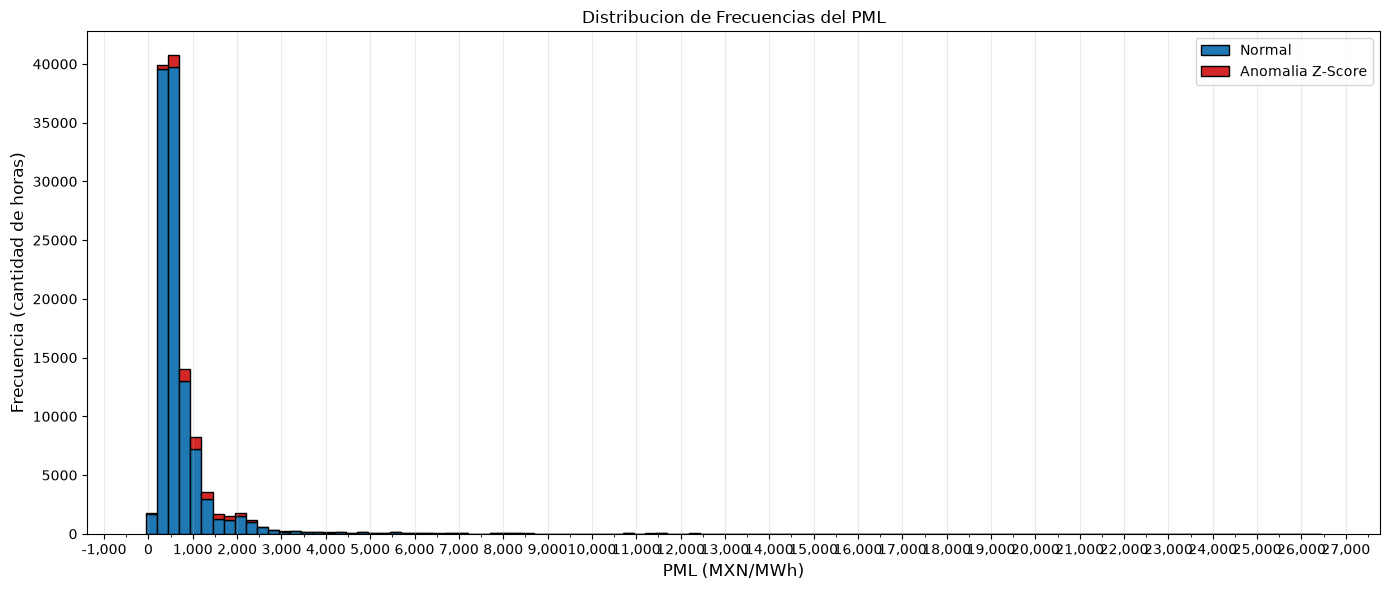

In [20]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

# Separar los datos para pintarlos diferente
normales = df_nodo[df_nodo['es_anomalia'] == 0]['pml']
anomalias = df_nodo[df_nodo['es_anomalia'] == 1]['pml']

fig, ax = plt.subplots(figsize=(14, 6))

# Usar intervalos de 1 MXN/MWh para cada barra
pml_min = np.floor(df_nodo['pml'].min())
pml_max = np.ceil(df_nodo['pml'].max())
bins = np.arange(pml_min, pml_max + 250, 250)

ax.hist(
    [normales, anomalias],
    bins=bins,
    stacked=True,
    color=['#1f77b4', '#d62728'],
    edgecolor='black',
    label=['Normal', 'Anomalia Z-Score']
)

ax.set_title('Distribucion de Frecuencias del PML')
ax.set_xlabel('PML (MXN/MWh)', fontsize=12)
ax.set_ylabel('Frecuencia (cantidad de horas)', fontsize=12)

# Mostrar una marca cada 1,000 MXN/MWh y marcas secundarias cada 500
ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_minor_locator(MultipleLocator(500))
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, position: f'{value:,.0f}'))
ax.grid(axis='x', which='major', alpha=0.25)

ax.legend()
fig.tight_layout()
#ax.set_yscale('log')
plt.show()

#### Isolation Forest

In [21]:
# 1. Preparar las características (features) que evaluará el modelo
# Le pasamos una matriz 2D con el precio y la hora.
X = df_nodo[['pml', 'hora']]

# 2. Instanciar el modelo
# contamination=0.01: Le decimos que esperamos que aprox. el 1% de los datos sean anomalías.
# random_state=42: Fija la semilla aleatoria para que siempre te dé el mismo resultado.
modelo_if = IsolationForest(contamination=0.01, random_state=42)

# 3. El modelo entrena (construye el bosque) y predice (aísla los puntos)
# scikit-learn devuelve: 1 para "Normal" y -1 para "Anomalía"
predicciones = modelo_if.fit_predict(X)

# 4. Traducir el resultado a nuestra regla de negocio
# Convertimos los -1 en 1 (Anomalía) y los 1 en 0 (Normal) para que coincida con tu Z-Score
df_nodo['anomalia_iforest'] = np.where(predicciones == -1, 1, 0)

# 5. Imprimir el "Frente a Frente"
total_zscore = df_nodo['es_anomalia'].sum()
total_iforest = df_nodo['anomalia_iforest'].sum()
coincidencias = len(df_nodo[(df_nodo['es_anomalia'] == 1) & (df_nodo['anomalia_iforest'] == 1)])

print(f"Total de registros: {len(df_nodo)}")
print(f"Anomalías por Z-Score (Estadística): {total_zscore}")
print(f"Anomalías por Isolation Forest (ML): {total_iforest}")
print(f"Puntos donde AMBOS modelos coinciden: {coincidencias}")

Total de registros: 118152
Anomalías por Z-Score (Estadística): 5870
Anomalías por Isolation Forest (ML): 1182
Puntos donde AMBOS modelos coinciden: 282


#### IQR

In [34]:
def getIQR(df_nodo):
    # 1. Calculamos el Cuartil 1 (25%) y Cuartil 3 (75%)
    Q1 = df_nodo['pml'].quantile(0.25)
    Q3 = df_nodo['pml'].quantile(0.75)
    
    # 2. Calculamos el Rango Intercuartílico
    IQR = Q3 - Q1
    
    # 3. Definimos los límites (el multiplicador 1.5 es el estándar de la industria)
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # 4. Etiquetamos las anomalías
    df_nodo['anomalia_iqr'] = np.where(
        (df_nodo['pml'] < limite_inferior) | (df_nodo['pml'] > limite_superior), 
        1, 
        0
    )
    
    return df_nodo

In [44]:
# Lista para guardar los resultados de cada nodo
df_resultados = []

print("Iniciando procesamiento de los 9 nodos...")

for nodo in df['nodo'].unique():
    print(f"Procesando nodo: {nodo}")
    
    # 1. Aislar el nodo y ordenar cronológicamente
    df_actual = df[df['nodo'] == nodo].copy()
    df_actual['pml'] = pd.to_numeric(df_actual['pml'])
    df_actual = df_actual.sort_values('fecha_hora').reset_index(drop=True)
    
    # 2. Aplicar Método 1: Z-Score (Requiere orden cronológico)
    df_actual = getGlobalZscore(df_actual, nodo) # Asumiendo que ajustaste tu función para que solo reciba df_actual
    
    # 3. Aplicar Método 2: Isolation Forest
    df_actual = getIsolationForest(df_actual)
    
    # 4. Aplicar Método 3: IQR
    df_actual = getIQR(df_actual)
    
    # 5. Guardar el nodo procesado en la lista
    df_resultados.append(df_actual)

# 6. Unir todo en el DataFrame Maestro y exportar
df_maestro = pd.concat(df_resultados, ignore_index=True)
df_maestro.to_csv('cenace_anomalias_detectadas.csv', index=False)

print(f"\n¡Pipeline terminado! Archivo exportado con {len(df_maestro)} registros.")

Iniciando procesamiento de los 9 nodos...
Procesando nodo: 06AEO-115
Procesando nodo: 06AHM-400
Procesando nodo: 06FRO-115
Procesando nodo: 06GRA-115
Procesando nodo: 06MON-115
Procesando nodo: 06MON-230
Procesando nodo: 06RGS-115
Procesando nodo: 06TKS-115
Procesando nodo: 06XOC-115

¡Pipeline terminado! Archivo exportado con 118152 registros.


### Track B

## Task 3: Visualization & Reporting​

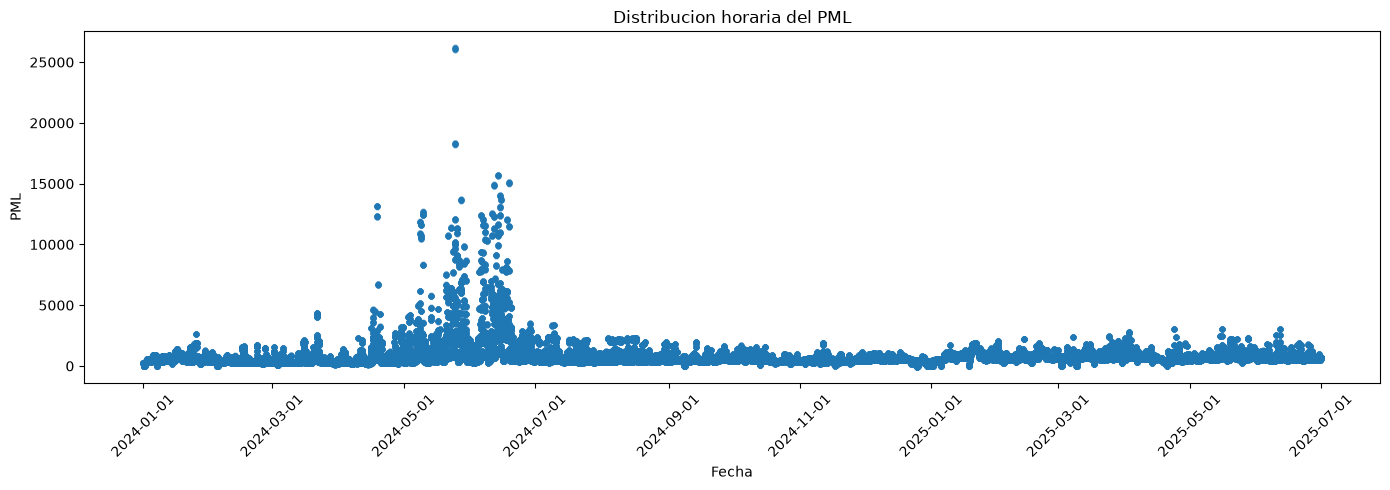

In [45]:
import matplotlib.dates as mdates

df_nodo['fecha'] = pd.to_datetime(df_nodo['fecha']).dt.date
df_nodo['fecha_hora'] = pd.to_datetime(df_nodo['fecha_hora'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(
    mdates.date2num(df_nodo['fecha_hora']),
    df_nodo['pml'],
    alpha=0.45,
    s=12
)
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_title('Distribucion horaria del PML')
ax.set_xlabel('Fecha')
ax.set_ylabel('PML')
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()

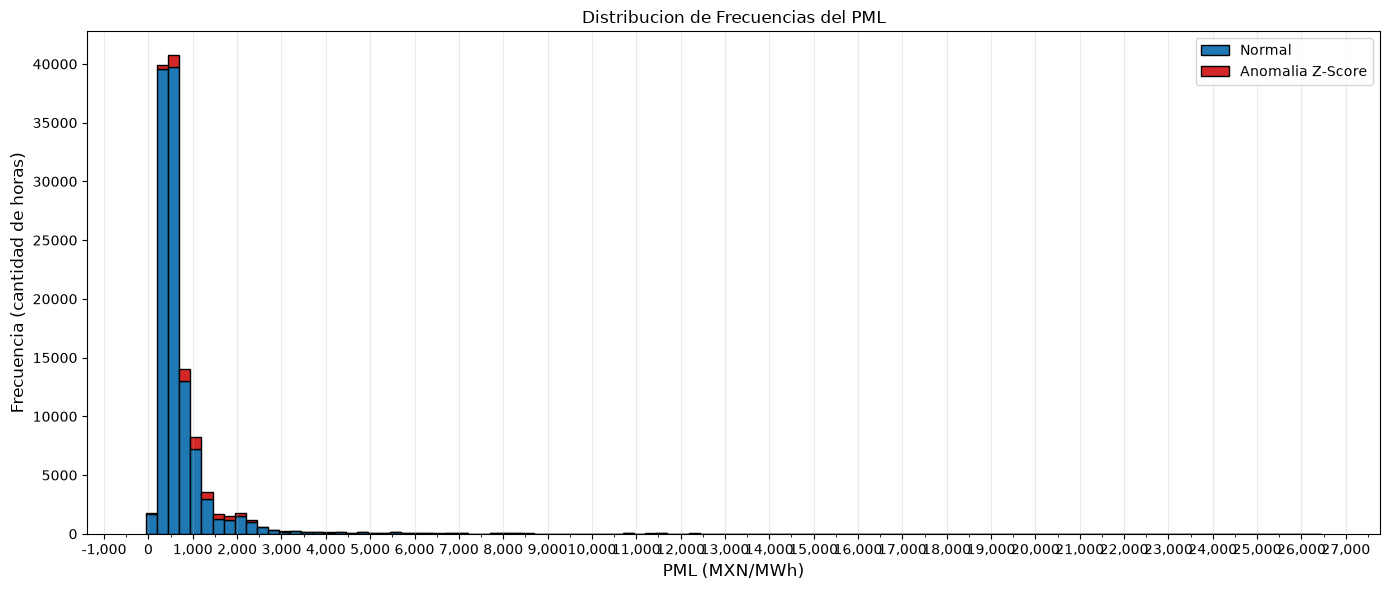

In [26]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

# Separar los datos para pintarlos diferente
normales = df_nodo[df_nodo['es_anomalia'] == 0]['pml']
anomalias = df_nodo[df_nodo['es_anomalia'] == 1]['pml']

fig, ax = plt.subplots(figsize=(14, 6))

# Usar intervalos de 1 MXN/MWh para cada barra
pml_min = np.floor(df_nodo['pml'].min())
pml_max = np.ceil(df_nodo['pml'].max())
bins = np.arange(pml_min, pml_max + 250, 250)

ax.hist(
    [normales, anomalias],
    bins=bins,
    stacked=True,
    color=['#1f77b4', '#d62728'],
    edgecolor='black',
    label=['Normal', 'Anomalia Z-Score']
)

ax.set_title('Distribucion de Frecuencias del PML')
ax.set_xlabel('PML (MXN/MWh)', fontsize=12)
ax.set_ylabel('Frecuencia (cantidad de horas)', fontsize=12)

# Mostrar una marca cada 1,000 MXN/MWh y marcas secundarias cada 500
ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_minor_locator(MultipleLocator(500))
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, position: f'{value:,.0f}'))
ax.grid(axis='x', which='major', alpha=0.25)

ax.legend()
fig.tight_layout()
#ax.set_yscale('log')
plt.show()

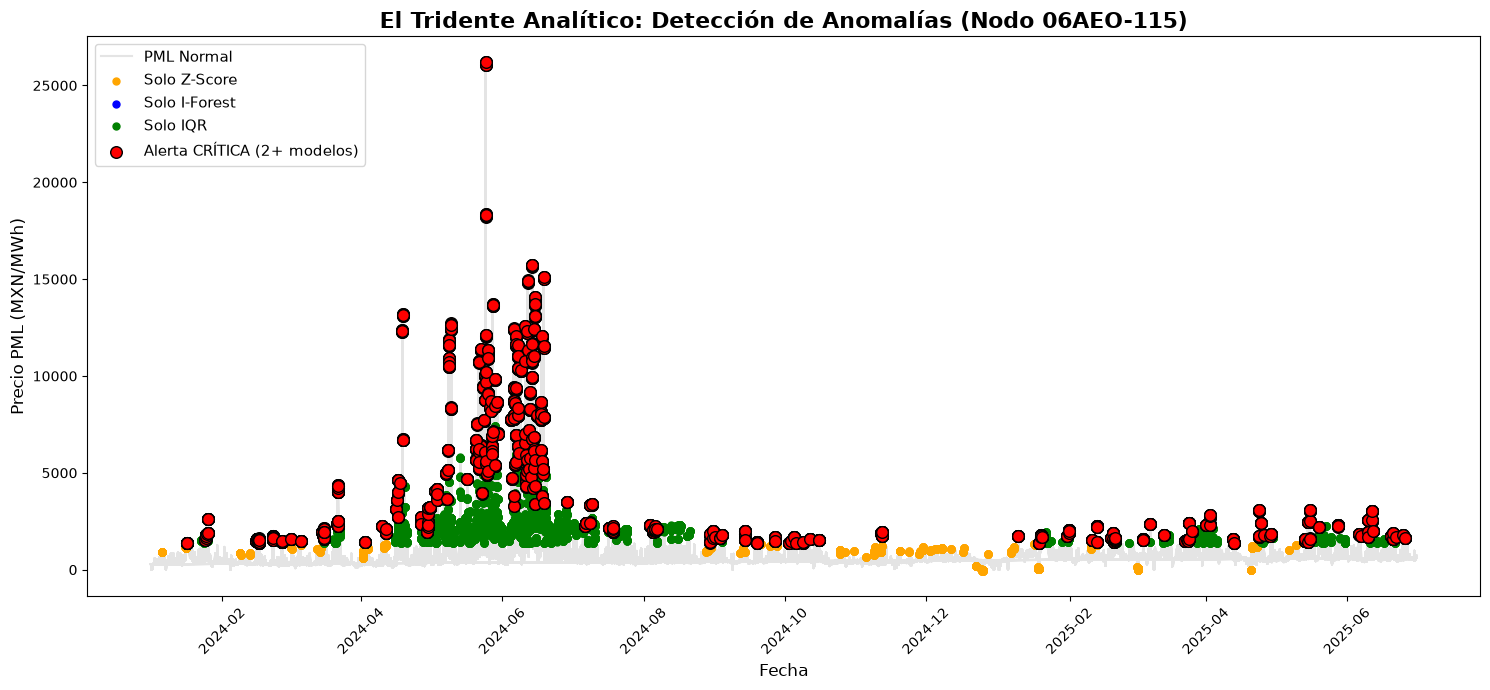

In [47]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Crear un sistema de "votos" sumando las banderas de los 3 modelos
# Nota: Ajusta 'es_anomalia' si en tu DataFrame actual ya le cambiaste el nombre a 'anomalia_zscore'
df_maestro['votos_anomalia'] = df_maestro['anomalia_zscore'] + df_maestro['anomalia_iforest'] + df_maestro['anomalia_iqr']

# 2. Separar los datos
# Los que fueron detectados por UN SOLO modelo
solo_zscore = df_maestro[(df_maestro['anomalia_zscore'] == 1) & (df_maestro['votos_anomalia'] == 1)]
solo_iforest = df_maestro[(df_maestro['anomalia_iforest'] == 1) & (df_maestro['votos_anomalia'] == 1)]
solo_iqr = df_maestro[(df_maestro['anomalia_iqr'] == 1) & (df_maestro['votos_anomalia'] == 1)]

# Los que fueron detectados por 2 o 3 modelos al mismo tiempo
criticas = df_maestro[df_maestro['votos_anomalia'] >= 2]

# 3. Configurar el lienzo
fig, ax = plt.subplots(figsize=(15, 7))

# 4. Dibujar la línea base (Todos los precios normales)
ax.plot(df_maestro['fecha_hora'], df_maestro['pml'], color='lightgray', alpha=0.6, label='PML Normal', zorder=1)

# 5. Dibujar las anomalías solitarias
ax.scatter(solo_zscore['fecha_hora'], solo_zscore['pml'], color='orange', s=25, label='Solo Z-Score', zorder=2)
ax.scatter(solo_iforest['fecha_hora'], solo_iforest['pml'], color='blue', s=25, label='Solo I-Forest', zorder=3)
ax.scatter(solo_iqr['fecha_hora'], solo_iqr['pml'], color='green', s=25, label='Solo IQR', zorder=4)

# 6. Dibujar las coincidencias (El consenso de los modelos)
ax.scatter(criticas['fecha_hora'], criticas['pml'], color='red', s=70, edgecolor='black', label='Alerta CRÍTICA (2+ modelos)', zorder=5)

# 7. Formato y diseño
ax.set_title('El Tridente Analítico: Detección de Anomalías (Nodo 06AEO-115)', fontsize=16, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Precio PML (MXN/MWh)', fontsize=12)

# Formatear el eje X para que las fechas se vean bien
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

ax.legend(fontsize=11, loc='upper left')
fig.tight_layout()
plt.show()

## Pipeline Functions Draft

In [43]:
def getGlobalZscore(df, nodo):
    df = df[df['nodo'] == nodo].copy()
    df['pml'] = pd.to_numeric(df['pml'])
    df = df.sort_values('fecha_hora').reset_index(drop=True)

    ventana = 168
    df['media_movil'] = df['pml'].rolling(window=ventana, min_periods=1).mean()
    df['std_movil'] = df['pml'].rolling(window=ventana, min_periods=1).std()
    df['z_score'] = np.where(
        df['std_movil'] > 0,
        (df['pml'] - df['media_movil']) / df['std_movil'],
        0
    )
    df['anomalia_zscore'] = np.where(df['z_score'].abs() > 3, 1, 0)
    return df

In [30]:
zscores = []
for nodo in df['nodo'].unique():
    zscore = getGlobalZscore(df, nodo)
    zscores.append(zscore)

zscore_result = pd.concat(zscores, ignore_index=True).sort_values('fecha_hora').reset_index(drop=True)



In [32]:
zscore_result[zscore_result['es_anomalia_zscore'] == 1]

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo,fecha_hora,media_movil,std_movil,z_score,es_anomalia_zscore
1026,2024-01-05,18,933.98,1337.01,-112.68,-290.34,06MON-230,2024-01-05 18:00:00,341.940609,154.237717,3.838486,1
1027,2024-01-05,18,934.01,1337.01,-112.68,-290.32,06MON-115,2024-01-05 18:00:00,341.960087,154.247621,3.838308,1
1028,2024-01-05,18,934.93,1337.01,-111.80,-290.28,06RGS-115,2024-01-05 18:00:00,342.263217,154.395547,3.838626,1
1029,2024-01-05,18,936.84,1337.01,-109.87,-290.31,06XOC-115,2024-01-05 18:00:00,342.705478,154.655322,3.841669,1
1030,2024-01-05,18,931.91,1337.01,-115.15,-289.96,06AHM-400,2024-01-05 18:00:00,341.496522,153.977522,3.834413,1
...,...,...,...,...,...,...,...,...,...,...,...,...
117040,2025-06-25,20,1645.81,1688.03,-42.22,0.00,06TKS-115,2025-06-25 20:00:00,654.624881,272.872404,3.632412,1
117041,2025-06-25,20,1650.97,1688.03,-37.06,0.00,06RGS-115,2025-06-25 20:00:00,656.497560,273.676307,3.633754,1
117042,2025-06-25,20,1645.44,1688.03,-42.60,0.00,06FRO-115,2025-06-25 20:00:00,654.488810,272.815979,3.632306,1
117043,2025-06-25,20,1653.67,1688.03,-34.36,0.00,06AEO-115,2025-06-25 20:00:00,657.883452,274.119571,3.632672,1


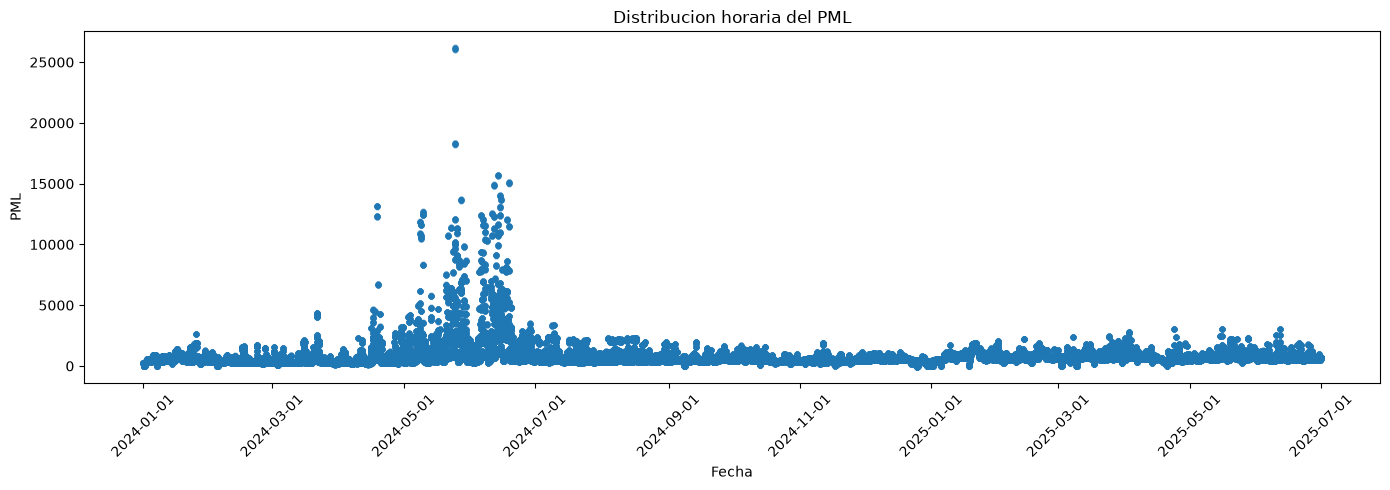

In [33]:
import matplotlib.dates as mdates

zscore_result['fecha'] = pd.to_datetime(df_nodo['fecha']).dt.date
zscore_result['fecha_hora'] = pd.to_datetime(df_nodo['fecha_hora'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(
    mdates.date2num(zscore_result['fecha_hora']),
    df_nodo['pml'],
    alpha=0.45,
    s=12
)
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_title('Distribucion horaria del PML')
ax.set_xlabel('Fecha')
ax.set_ylabel('PML')
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()

In [36]:
def getIsolationForest(df_nodo, contamination=0.01, random_state=42):
    # 1. Preparar las características (features) que evaluará el modelo
    X = df_nodo[['pml', 'hora']]

    # 2. Instanciar el modelo
    modelo_if = IsolationForest(contamination=contamination, random_state=random_state)

    # 3. El modelo entrena (construye el bosque) y predice (aísla los puntos)
    predicciones = modelo_if.fit_predict(X)

    # 4. Traducir el resultado a nuestra regla de negocio
    df_nodo['anomalia_iforest'] = np.where(predicciones == -1, 1, 0)

    return df_nodo
